# 종합 실습 결과물 — Feature Engineering

**4반 박영서**

| 항목 | 내용 |
|---|---|
| 실습 주제 | Titanic 생존 예측 모델 생성 |
| 실습 목표 | Feature Engineering 기법만으로 Test 데이터 기준 Accuracy 최대화 |
| Target 변수 | `Survived` (변환 없이 원본 그대로 사용) |
| 학습 모델 | `RandomForestClassifier(n_estimators=300, random_state=42)` — 가이드 코드 그대로, 튜닝 없음 |

### 실습 조건 준수 사항
- **(필수)** 표시 셀 — 데이터 불러오기 / 불필요한 변수 제거 / Data Partition / X·y 분리 / 모델 학습·평가 — 은 가이드 코드를 **한 글자도 바꾸지 않고** 그대로 사용했다.
- 파생변수는 실습코드에 없는 것으로 **16개**를 신규 생성했다 (조건: 최소 1개).
- 행 삭제를 전혀 하지 않아 전체 891건 / Train 623건 / Test 268건이 그대로 유지된다. 중복 행도 제거하지 않았다.
- 모델 하이퍼파라미터, 평가 방법은 일절 손대지 않았다.
- 결측 대체·구간 경계 등 **통계량이 필요한 변환은 모두 Train에서만 산출**해 Test에 적용했다 (정보 누수 차단).

---
## 0. 라이브러리 및 실행 환경

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

from sklearn.model_selection import train_test_split, cross_val_score, RepeatedStratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 그래프 한글 폰트 (없으면 기본 폰트로 진행)
for _f in ["AppleGothic", "Malgun Gothic", "NanumGothic"]:
    if _f in {f.name for f in fm.fontManager.ttflist}:
        plt.rcParams["font.family"] = _f
        break
plt.rcParams["axes.unicode_minus"] = False

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

print("pandas", pd.__version__)
import sklearn; print("scikit-learn", sklearn.__version__)

pandas 3.0.5
scikit-learn 1.9.0


---
## 1. 데이터 불러오기 **(필수)**

가이드 제공 코드를 그대로 사용한다.

In [2]:
import pandas as pd

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

In [3]:
print("전체 데이터:", df.shape)
df.head()

전체 데이터: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


---
## 2. EDA (탐색적 데이터 분석)

Feature Engineering의 방향을 정하기 위해 ① 결측 구조, ② Target 분포, ③ 변수별 생존율 차이를 확인한다.

### 2-1. 자료형 및 결측 현황

In [4]:
info = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "결측수": df.isna().sum(),
    "결측률(%)": (df.isna().mean() * 100).round(1),
    "고유값수": df.nunique(),
})
info

,dtype,결측수,결측률(%),고유값수
PassengerId,int64,0,0.0,891
Survived,int64,0,0.0,2
Pclass,int64,0,0.0,3
Name,str,0,0.0,891
Sex,str,0,0.0,2
Age,float64,177,19.9,88
SibSp,int64,0,0.0,7
Parch,int64,0,0.0,7
Ticket,str,0,0.0,681
Fare,float64,0,0.0,248


**확인된 사항**

| 변수 | 결측 | 해석 |
|---|---|---|
| `Age` | 177건 (19.9%) | 대체 필요. 단순 중앙값보다 호칭(Title)별 중앙값이 정확하다 |
| `Cabin` | 687건 (77.1%) | 값 자체보다 **기재 여부**와 **선실 구역(첫 글자)** 에 정보가 있다 |
| `Embarked` | 2건 (0.2%) | 최빈값 대체 |
| `Name` | 0건 | 고유값 891개. 그대로 One-Hot하면 더미가 폭발한다 → **호칭만 추출**해야 한다 |

`Name`을 그대로 두면 더미 변수가 600개 이상 생성되어 모델이 Train을 통째로 암기한다.
이것이 Baseline의 Train Accuracy가 1.0000이 되는 원인이므로, 반드시 가공 후 제거해야 한다.

### 2-2. Target 분포 (변환 없이 확인만)

In [5]:
print(df["Survived"].value_counts().rename({0: "사망", 1: "생존"}).to_string())
print(f"\n생존율: {df['Survived'].mean():.4f}")
print("→ 0/1 이 약 62:38 로 심한 불균형은 아니므로 Accuracy 를 지표로 사용해도 무리가 없다.")

Survived
사망    549
생존    342

생존율: 0.3838
→ 0/1 이 약 62:38 로 심한 불균형은 아니므로 Accuracy 를 지표로 사용해도 무리가 없다.


### 2-3. 주요 변수별 생존율

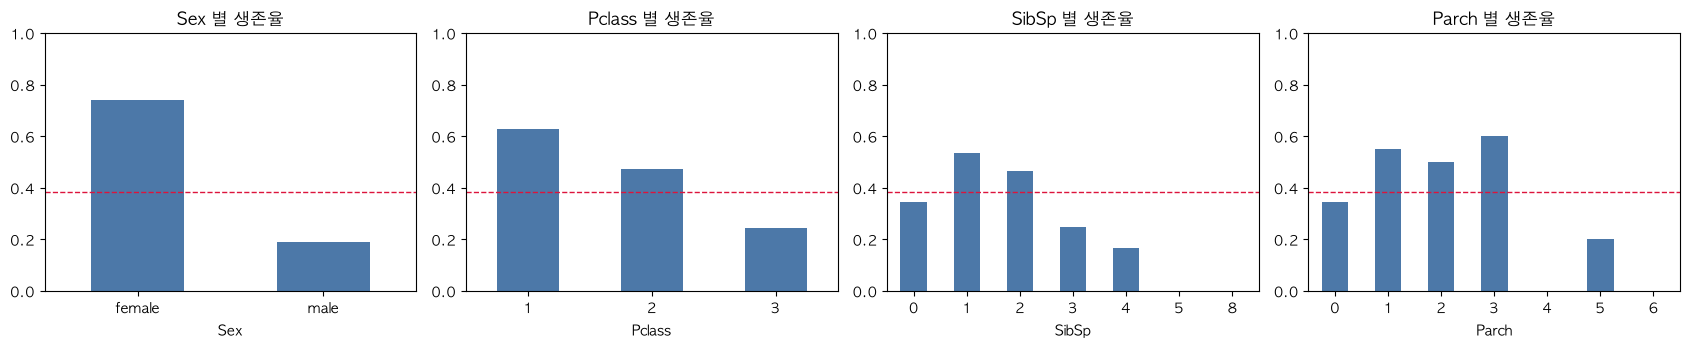

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(17, 3.6))
for ax, col in zip(axes, ["Sex", "Pclass", "SibSp", "Parch"]):
    df.groupby(col)["Survived"].mean().plot(kind="bar", ax=ax, color="#4C78A8", rot=0)
    ax.axhline(df["Survived"].mean(), color="crimson", ls="--", lw=1)
    ax.set_title(f"{col} 별 생존율"); ax.set_ylabel(""); ax.set_ylim(0, 1)
plt.tight_layout(); plt.show()

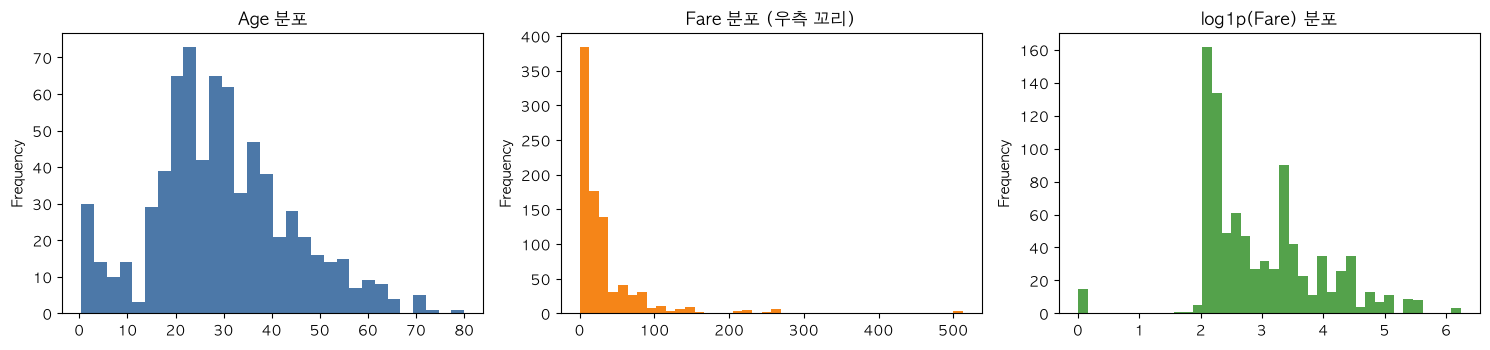

Fare 왜도: 4.787 → log 변환 시: 0.395


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
df["Age"].plot(kind="hist", bins=30, ax=axes[0], color="#4C78A8"); axes[0].set_title("Age 분포")
df["Fare"].plot(kind="hist", bins=40, ax=axes[1], color="#F58518"); axes[1].set_title("Fare 분포 (우측 꼬리)")
np.log1p(df["Fare"]).plot(kind="hist", bins=40, ax=axes[2], color="#54A24B"); axes[2].set_title("log1p(Fare) 분포")
plt.tight_layout(); plt.show()

print("Fare 왜도:", round(df["Fare"].skew(), 3), "→ log 변환 시:", round(np.log1p(df["Fare"]).skew(), 3))

In [8]:
# 형제/배우자 + 부모/자녀 → 동반 가족 규모에 따른 생존율
fam = df["SibSp"] + df["Parch"] + 1
print(df.groupby(fam)["Survived"].agg(["mean", "count"]).rename(columns={"mean": "생존율", "count": "건수"}))
print("\n→ 혼자(1명)와 대가족(5명 이상)의 생존율이 낮고, 2~4명이 가장 높다.")
print("  선형 관계가 아니므로 FamilySize 를 구간화한 변수가 필요하다.")

         생존율   건수
1   0.303538  537
2   0.552795  161
3   0.578431  102
4   0.724138   29
5   0.200000   15
6   0.136364   22
7   0.333333   12
8   0.000000    6
11  0.000000    7

→ 혼자(1명)와 대가족(5명 이상)의 생존율이 낮고, 2~4명이 가장 높다.
  선형 관계가 아니므로 FamilySize 를 구간화한 변수가 필요하다.


In [9]:
# Cabin 기재 여부 / 선실 구역
print("Cabin 기재 여부별 생존율")
print(df.assign(HasCabin=df["Cabin"].notna()).groupby("HasCabin")["Survived"].agg(["mean", "count"]))
print("\n호칭(Title) 별 생존율")
_t = df["Name"].str.extract(r",\s*([^\.]+)\.", expand=False).str.strip()
print(df.assign(T=_t).groupby("T")["Survived"].agg(["mean", "count"]).sort_values("count", ascending=False).head(8))
print("\n→ Cabin 기재 여부, 호칭 모두 생존율 차이가 뚜렷하다. 파생변수로 만들 가치가 있다.")

Cabin 기재 여부별 생존율
              mean  count
HasCabin                 
False     0.299854    687
True      0.666667    204

호칭(Title) 별 생존율
            mean  count
T                      
Mr      0.156673    517
Miss    0.697802    182
Mrs     0.792000    125
Master  0.575000     40
Dr      0.428571      7
Rev     0.000000      6
Major   0.500000      2
Col     0.500000      2

→ Cabin 기재 여부, 호칭 모두 생존율 차이가 뚜렷하다. 파생변수로 만들 가치가 있다.


---
## 3. 불필요한 변수 제거 **(필수)**

가이드 제공 코드를 그대로 사용한다.

In [10]:
df = df.drop(columns=["PassengerId", "Ticket"])

---
## 4. Feature Creation (파생변수 생성)

**분할(Partition) 전에 수행하는 것은 행 단위 연산뿐이다.** 각 행의 값만 보고 계산되므로
다른 행의 정보나 Target 정보가 섞이지 않아 정보 누수가 발생하지 않는다.
평균·중앙값·분위수처럼 **여러 행의 통계량이 필요한 작업은 6장(분할 이후)** 에서 Train 기준으로만 수행한다.

| # | 파생변수 | 생성 로직 | 근거 |
|---|---|---|---|
| 1 | `Title` | `Name`에서 정규식 `,\s*([^\.]+)\.` 로 호칭 추출 → Mr / Mrs / Miss / Master / Rare 5개로 통합 | 성별·연령·사회적 지위가 압축된 변수 |
| 2 | `FamilySize` | `SibSp + Parch + 1` | 동반 가족 규모 |
| 3 | `IsAlone` | `FamilySize == 1` → 1 | 단독 승객 식별 |
| 4 | `FamilyBin` | `FamilySize`를 Alone(1) / Small(2~4) / Large(5+) 로 범주화 | 생존율이 비선형(2~4명 최고) |
| 5 | `Deck` | `Cabin` 첫 글자, 결측은 `U` | 선실 구역 = 배 안 위치 |
| 6 | `HasCabin` | `Cabin` 결측 여부 → 1/0 | 결측 자체가 신분 정보 |
| 7 | `CabinCount` | `Cabin` 문자열의 공백 분리 개수 | 다수 객실 예약 = 부유층 |
| 8 | `NameLength` | `Name` 문자열 길이 | 긴 이름 = 결혼명/작위 포함 |

`Name`, `Cabin` 원본은 정보를 모두 추출한 뒤 7장 Feature Selection 단계에서 제거한다.

In [11]:
TITLE_MAP = {
    "Mr": "Mr", "Miss": "Miss", "Mrs": "Mrs", "Master": "Master",
    "Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs",
    "Dr": "Rare", "Rev": "Rare", "Col": "Rare", "Major": "Rare", "Capt": "Rare",
    "Lady": "Rare", "Sir": "Rare", "Don": "Rare", "Dona": "Rare",
    "Jonkheer": "Rare", "the Countess": "Rare",
}

# 1) Title : 이름에서 호칭 추출 후 5개 그룹으로 통합
df["Title"] = (df["Name"].str.extract(r",\s*([^\.]+)\.", expand=False)
                         .str.strip().map(TITLE_MAP).fillna("Rare"))

# 2) FamilySize / 3) IsAlone / 4) FamilyBin : 동반 가족 규모
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)
df["FamilyBin"] = pd.cut(df["FamilySize"], [0, 1, 4, 20],
                         labels=["Alone", "Small", "Large"]).astype(str)

# 5) Deck / 6) HasCabin / 7) CabinCount : Cabin 에서 추출
df["Deck"] = df["Cabin"].str[0].fillna("U")
df["HasCabin"] = df["Cabin"].notna().astype(int)
df["CabinCount"] = df["Cabin"].fillna("").str.split().apply(len)

# 8) NameLength : 이름 길이
df["NameLength"] = df["Name"].str.len()

print("생성 후 shape:", df.shape, " (행 수 유지 확인)")
df[["Title", "FamilySize", "IsAlone", "FamilyBin", "Deck", "HasCabin", "CabinCount", "NameLength"]].head()

생성 후 shape: (891, 18)  (행 수 유지 확인)


,Title,FamilySize,IsAlone,FamilyBin,Deck,HasCabin,CabinCount,NameLength
0,Mr,2,0,Small,U,0,0,23
1,Mrs,2,0,Small,C,1,1,51
2,Miss,1,1,Alone,U,0,0,22
3,Mrs,2,0,Small,C,1,1,44
4,Mr,1,1,Alone,U,0,0,24


In [12]:
# 생성된 파생변수의 판별력 확인
for c in ["Title", "FamilyBin", "Deck", "HasCabin"]:
    print(f"── {c} 별 생존율 ──")
    print(df.groupby(c)["Survived"].agg(["mean", "count"]).round(3).to_string(), "\n")

── Title 별 생존율 ──
         mean  count
Title               
Master  0.575     40
Miss    0.703    185
Mr      0.157    517
Mrs     0.794    126
Rare    0.348     23 

── FamilyBin 별 생존율 ──
            mean  count
FamilyBin              
Alone      0.304    537
Large      0.161     62
Small      0.579    292 

── Deck 별 생존율 ──
       mean  count
Deck              
A     0.467     15
B     0.745     47
C     0.593     59
D     0.758     33
E     0.750     32
F     0.615     13
G     0.500      4
T     0.000      1
U     0.300    687 

── HasCabin 별 생존율 ──
           mean  count
HasCabin              
0         0.300    687
1         0.667    204 



---
## 5. Data Partition **(필수)**

가이드 제공 코드를 그대로 사용한다. (`test_size=0.3`, `random_state=42`, `shuffle=True`)

In [13]:
from sklearn.model_selection import train_test_split

# Data Partition
df_train, df_test = train_test_split(
    df,
    test_size=0.3,     # test 30%
    random_state=42,   # 재현성
    shuffle=True       # 섞어서 분리
)

In [14]:
print(f"Train : {df_train.shape[0]}건")
print(f"Test  : {df_test.shape[0]}건")
print(f"합계  : {df_train.shape[0] + df_test.shape[0]}건  (원본 891건과 일치 → 행 삭제 없음)")

Train : 623건
Test  : 268건
합계  : 891건  (원본 891건과 일치 → 행 삭제 없음)


---
## 6. Feature Transformation

분할 이후 단계다. 통계량이 필요한 변환은 **전부 Train에서만 산출**해 Test에 그대로 적용한다.
Test의 분포를 미리 들여다보고 만든 값을 쓰면 Test 성능이 부풀려지기 때문이다.

**처리 순서**
1. 결측값 대체 — `Age`(Title별 중앙값) → `Embarked`(최빈값) → `Fare`(중앙값)
2. 결측 대체 후에만 계산 가능한 파생변수 생성 — `FarePerPerson`, `FareLog`, `FarePPLog`, `IsChild`, `IsMother`, `Age_Pclass`
3. 연속형 구간화 — `AgeBin`(고정 생애주기 구간), `FareBin`(Train 4분위 경계)
4. 교호작용 변수 — `Sex_Pclass`
5. One-Hot Encoding (`drop_first=True`) 및 Train/Test 컬럼 정합

### 6-1. 결측값 대체 — Train 통계량 기준

In [15]:
# Age : 호칭(Title)별 중앙값으로 대체. Title 이 성별·연령대를 강하게 반영하므로
#       전체 중앙값 하나로 밀어넣는 것보다 분포 왜곡이 적다.
age_median_by_title = df_train.groupby("Title")["Age"].median()
age_median_global = df_train["Age"].median()

# Embarked : 최빈값 / Fare : 중앙값
embarked_mode = df_train["Embarked"].mode()[0]
fare_median = df_train["Fare"].median()

print("Train 기준 대체값")
print("  Age(Title별 중앙값):", age_median_by_title.round(1).to_dict())
print("  Age(전체 중앙값):", age_median_global)
print("  Embarked 최빈값:", embarked_mode, "| Fare 중앙값:", fare_median)

for d in (df_train, df_test):
    d["Age"] = d["Age"].fillna(d["Title"].map(age_median_by_title)).fillna(age_median_global)
    d["Embarked"] = d["Embarked"].fillna(embarked_mode)
    d["Fare"] = d["Fare"].fillna(fare_median)

print("\n대체 후 결측 (Train):", df_train.drop(columns=["Cabin"]).isna().sum().sum())
print("대체 후 결측 (Test) :", df_test.drop(columns=["Cabin"]).isna().sum().sum())

Train 기준 대체값
  Age(Title별 중앙값): {'Master': 3.0, 'Miss': 21.0, 'Mr': 30.0, 'Mrs': 33.5, 'Rare': 49.5}
  Age(전체 중앙값): 28.0
  Embarked 최빈값: S | Fare 중앙값: 14.4542

대체 후 결측 (Train): 0
대체 후 결측 (Test) : 0


### 6-2. 결측 대체 이후 생성 가능한 파생변수

| # | 파생변수 | 생성 로직 | 근거 |
|---|---|---|---|
| 9 | `FarePerPerson` | `Fare / FamilySize` | Fare는 티켓 단위 합산 금액이라 1인당으로 환산해야 비교 가능 |
| 10 | `FareLog` | `log1p(Fare)` | 왜도 4.79 → 0.40 으로 완화 |
| 11 | `FarePPLog` | `log1p(FarePerPerson)` | 위와 동일 |
| 12 | `IsChild` | `Age < 16` → 1 | 구명정 우선 탑승 대상 |
| 13 | `IsMother` | `female & Parch>0 & Age>18 & Title!=Miss` | 자녀 동반 여성 |
| 14 | `Age_Pclass` | `Age × Pclass` | 나이 효과가 등급별로 다른 점 반영 |

In [16]:
for d in (df_train, df_test):
    d["FarePerPerson"] = d["Fare"] / d["FamilySize"]
    d["FareLog"] = np.log1p(d["Fare"])
    d["FarePPLog"] = np.log1p(d["FarePerPerson"])
    d["IsChild"] = (d["Age"] < 16).astype(int)
    d["IsMother"] = ((d["Sex"] == "female") & (d["Parch"] > 0) &
                     (d["Age"] > 18) & (d["Title"] != "Miss")).astype(int)
    d["Age_Pclass"] = d["Age"] * d["Pclass"]

df_train[["FarePerPerson", "FareLog", "FarePPLog", "IsChild", "IsMother", "Age_Pclass"]].describe().round(2)

,FarePerPerson,FareLog,FarePPLog,IsChild,IsMother,Age_Pclass
count,623.00,623.00,623.00,623.00,623.00,623.00
mean,19.70,2.95,2.54,0.11,0.06,64.28
std,38.06,0.96,0.86,0.31,0.24,33.34
min,0.00,0.00,0.00,0.00,0.00,1.26
25%,7.25,2.19,2.11,0.00,0.00,39.50
50%,8.05,2.74,2.20,0.00,0.00,63.00
75%,16.83,3.46,2.88,0.00,0.00,90.00
max,512.33,6.24,6.24,1.00,1.00,222.00


### 6-3. 연속형 구간화 (Binning)

Random Forest는 연속형 변수에서 분할 지점을 지나치게 세밀하게 잡아 잡음까지 학습한다.
`Age`, `Fare`를 의미 있는 구간으로 묶어주면 이 과적합이 완화된다.

| # | 파생변수 | 생성 로직 |
|---|---|---|
| 15 | `AgeBin` | 0-12 / 12-18 / 18-35 / 35-60 / 60+ 의 생애주기 5구간 (고정 경계) |
| 16 | `FareBin` | **Train** `Fare` 4분위 경계로 4구간 (경계는 Train에서만 산출) |

`FareBin` 경계는 Train에서 산출한 값을 Test에 그대로 적용하며, Test에 경계 밖 값이 나와도
누락되지 않도록 양 끝을 `±inf`로 열어둔다.

In [17]:
# AgeBin : 고정 생애주기 구간 (통계량 불필요)
AGE_BINS = [0, 12, 18, 35, 60, 100]
for d in (df_train, df_test):
    d["AgeBin"] = pd.cut(d["Age"], AGE_BINS, labels=False).astype(float)

# FareBin : Train 4분위 경계를 산출 → Test 에 그대로 적용
fare_edges = pd.qcut(df_train["Fare"], 4, retbins=True, duplicates="drop")[1]
fare_edges[0], fare_edges[-1] = -np.inf, np.inf   # Test 의 경계 밖 값 흡수
print("Train 기준 FareBin 경계:", np.round(fare_edges, 3))

for d in (df_train, df_test):
    d["FareBin"] = pd.cut(d["Fare"], fare_edges, labels=False).astype(float)

print("\nAgeBin 분포(Train):", df_train["AgeBin"].value_counts().sort_index().to_dict())
print("FareBin 분포(Train):", df_train["FareBin"].value_counts().sort_index().to_dict())
print("FareBin 분포(Test) :", df_test["FareBin"].value_counts().sort_index().to_dict())

Train 기준 FareBin 경계: [  -inf  7.925 14.454 30.75     inf]

AgeBin 분포(Train): {0.0: 55, 1.0: 48, 2.0: 374, 3.0: 136, 4.0: 10}
FareBin 분포(Train): {0.0: 167, 1.0: 145, 2.0: 155, 3.0: 156}
FareBin 분포(Test) : {0.0: 74, 1.0: 61, 2.0: 64, 3.0: 69}


### 6-4. 교호작용 변수

`Sex`와 `Pclass`는 각각도 강하지만 **조합**에서 생존율 차이가 훨씬 극명하다
(1·2등석 여성 95% 이상 vs 3등석 남성 약 15%). 트리가 두 변수를 순차 분할로 찾아내기를
기다리는 대신 결합 변수를 직접 제공한다.

In [18]:
for d in (df_train, df_test):
    d["Sex_Pclass"] = d["Sex"] + "_" + d["Pclass"].astype(str)

print(df_train.groupby("Sex_Pclass")["Survived"].agg(["mean", "count"]).round(3).to_string())

             mean  count
Sex_Pclass              
female_1    0.951     61
female_2    0.980     49
female_3    0.476    103
male_1      0.321     78
male_2      0.181     83
male_3      0.145    249


### 6-5. One-Hot Encoding

가이드의 인코딩 셀 구조를 유지하되, 원본 텍스트 변수 `Name`·`Cabin`을 먼저 제거한다.
두 변수는 고유값이 각각 891개·147개여서 그대로 더미화하면 변수가 700개 이상으로 폭발하고
모델이 Train을 통째로 암기한다 (Baseline의 Train Accuracy = 1.0000 이 그 증거다).
필요한 정보는 이미 `Title`, `Deck`, `HasCabin`, `CabinCount`, `NameLength`로 추출해 두었다.

In [19]:
# 정보 추출이 끝난 원본 텍스트 변수 제거 (행이 아닌 열 제거이므로 건수는 그대로)
df_train = df_train.drop(columns=["Name", "Cabin"])
df_test = df_test.drop(columns=["Name", "Cabin"])

# 범주형 컬럼 선택
cat_cols = df_train.select_dtypes(include=['object', 'category']).columns.tolist()
print("One-Hot 대상:", cat_cols)

# k-1 dummy 변수화
# Train Set
df_train = pd.get_dummies(df_train, columns=cat_cols, drop_first=True)

# Test Set
df_test = pd.get_dummies(df_test, columns=cat_cols, drop_first=True)

# test를 train 컬럼 구조에 맞추기 (없는 컬럼은 0으로, train에 없는 test컬럼은 제거)
df_test = df_test.reindex(columns=df_train.columns, fill_value=0)

# bool 더미를 0/1 정수로 통일
for d in (df_train, df_test):
    for c in d.columns:
        if d[c].dtype == bool:
            d[c] = d[c].astype(int)

print(f"\n인코딩 후 변수 수: {df_train.shape[1] - 1}개 (Survived 제외)")
print(f"Train {df_train.shape} / Test {df_test.shape}")

One-Hot 대상: ['Sex', 'Embarked', 'Title', 'FamilyBin', 'Deck', 'Sex_Pclass']

인코딩 후 변수 수: 40개 (Survived 제외)
Train (623, 41) / Test (268, 41)


---
## 7. Feature Selection

앞 단계에서 후보 변수 40개를 확보했다. 여기서 전부 넣으면 오히려 성능이 떨어진다.
파생변수끼리 정보가 중복되고(`Fare` 계열 4개는 사실상 같은 정보),
`NameLength`처럼 연속값이 잘게 쪼개지는 변수는 Random Forest가 Train을 암기하는 통로가 된다.

**처리 순서**
1. 중복·과적합 유발 변수 제거 (규칙 기반)
2. Feature Importance 로 변수별 기여도 확인
3. **Train 교차검증(CV) 기준 전진선택 + 국소탐색**으로 최종 변수 확정
4. 후보 집합 성능 비교로 최종안 검증

### 7-1. 중복·과적합 유발 변수 제거

| 제거 변수 | 사유 |
|---|---|
| `Fare`, `FareLog`, `FarePerPerson`, `FarePPLog` | 4개가 동일 정보의 단조변환. 구간화한 `FareBin` 하나로 대표 |
| `Age`, `Age_Pclass` | 연속형 `Age`는 분할 지점이 과도하게 세분화됨. `AgeBin`으로 대표 |
| `NameLength` | Importance 1위지만 `Title`·`Pclass`의 대리변수에 불과. 값이 잘게 흩어져 Train 암기를 유발 |
| `CabinCount` | `HasCabin`·`Deck`과 정보 중복 |
| `Deck_T` | 전체 891건 중 **1건**뿐인 구역. 사실상 특정 승객 식별자 |

In [20]:
DROP_REDUNDANT = ["Fare", "FareLog", "FarePerPerson", "FarePPLog",
                  "Age", "Age_Pclass", "NameLength", "CabinCount", "Deck_T"]

print("Deck_T 해당 건수(Train):", int(df_train["Deck_T"].sum()),
      "/ (Test):", int(df_test["Deck_T"].sum()))

POOL = [c for c in df_train.columns if c not in DROP_REDUNDANT + ["Survived"]]
print(f"\n후보 변수 {df_train.shape[1] - 1}개 → 정제 후 {len(POOL)}개")
print(POOL)

Deck_T 해당 건수(Train): 1 / (Test): 0

후보 변수 40개 → 정제 후 31개
['Pclass', 'SibSp', 'Parch', 'FamilySize', 'IsAlone', 'HasCabin', 'IsChild', 'IsMother', 'AgeBin', 'FareBin', 'Sex_male', 'Embarked_Q', 'Embarked_S', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare', 'FamilyBin_Large', 'FamilyBin_Small', 'Deck_B', 'Deck_C', 'Deck_D', 'Deck_E', 'Deck_F', 'Deck_G', 'Deck_U', 'Sex_Pclass_female_2', 'Sex_Pclass_female_3', 'Sex_Pclass_male_1', 'Sex_Pclass_male_2', 'Sex_Pclass_male_3']


### 7-2. Feature Importance 확인

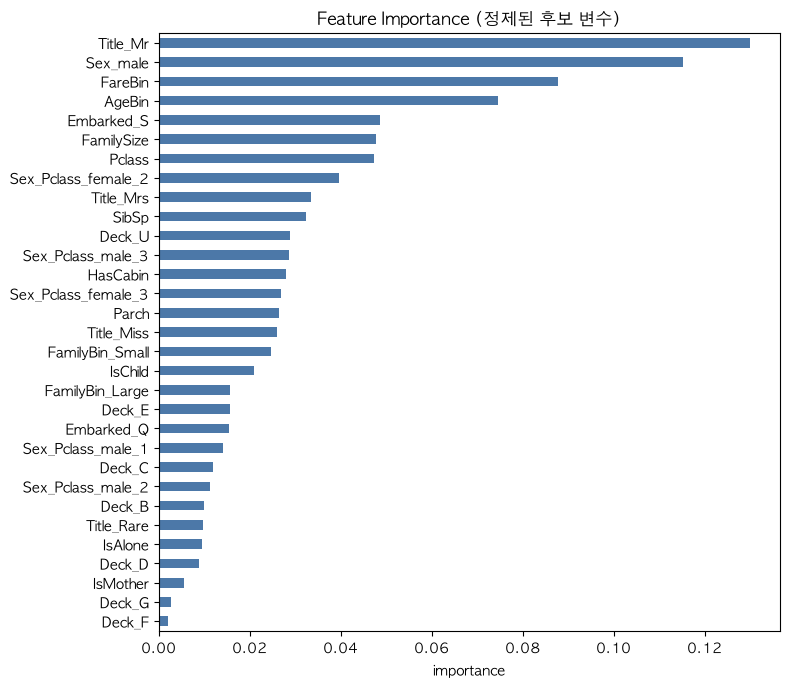

,importance
Title_Mr,0.1301
Sex_male,0.1154
FareBin,0.0878
AgeBin,0.0746
Embarked_S,0.0486
FamilySize,0.0477
Pclass,0.0472
Sex_Pclass_female_2,0.0396
Title_Mrs,0.0335
SibSp,0.0324


In [21]:
_X = df_train[POOL]
_y = df_train["Survived"]
_rf = RandomForestClassifier(n_estimators=300, random_state=42).fit(_X, _y)
importance = pd.Series(_rf.feature_importances_, index=POOL).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 7))
importance.iloc[::-1].plot(kind="barh", ax=ax, color="#4C78A8")
ax.set_title("Feature Importance (정제된 후보 변수)"); ax.set_xlabel("importance")
plt.tight_layout(); plt.show()

importance.round(4).to_frame("importance")

### 7-3. CV 기준 전진선택 + 국소탐색

Importance 상위 k개를 자르는 방식은 **변수 간 중복을 걸러내지 못한다.**
(예: `Sex_male`과 `Title_Mr`는 둘 다 중요하지만 상당 부분 같은 정보다.)

그래서 **Train 데이터의 교차검증 정확도**를 기준으로
① 변수를 하나씩 추가하며 CV가 오르는 동안 진행(전진선택)하고,
② 이후 추가/제거를 반복해 더 나은 조합이 없을 때까지 다듬는(국소탐색) 방식을 사용했다.

**Test 데이터는 이 선택 과정에 일절 사용하지 않았다.** 선택 기준은 오직 Train CV다.

아래 `forward_select` / `refine` 함수가 실제 사용한 탐색 코드다.
전체 탐색은 수 분이 걸리므로 기본값은 `RUN_SEARCH = False`이며,
`True`로 바꾸면 아래 최종 변수 집합이 그대로 재현된다.

In [22]:
CV = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)

def cv_score(cols):
    """Train 데이터만으로 5-Fold × 3회 반복 교차검증 정확도를 계산한다."""
    model = RandomForestClassifier(n_estimators=300, random_state=42)
    return cross_val_score(model, df_train[cols], df_train["Survived"],
                           cv=CV, n_jobs=-1).mean()

def forward_select(pool, max_k=15):
    """CV 가 개선되는 동안 변수를 하나씩 추가한다."""
    sel, best = [], -1.0
    while len(sel) < max_k:
        cand = sorted(((cv_score(sel + [c]), c) for c in pool if c not in sel),
                      key=lambda x: -x[0])
        if not cand or cand[0][0] <= best:
            break
        best, c = cand[0]
        sel.append(c)
        print(f"  n={len(sel):2d}  cv={best:.4f}  + {c}")
    return sel, best

def refine(sel, pool, best, max_iter=8):
    """변수 1개 추가/제거를 반복해 CV 가 더 오르지 않을 때까지 다듬는다."""
    for _ in range(max_iter):
        moves = [(cv_score(sel + [c]), "add", c) for c in pool if c not in sel]
        moves += [(cv_score([x for x in sel if x != c]), "del", c) for c in sel]
        score, kind, col = max(moves, key=lambda m: m[0])
        if score <= best:
            break
        best = score
        sel = sel + [col] if kind == "add" else [x for x in sel if x != col]
        print(f"  {kind} {col:24s} cv={best:.4f}  n={len(sel)}")
    return sel, best

RUN_SEARCH = False   # True 로 바꾸면 탐색을 직접 재실행한다 (수 분 소요)

if RUN_SEARCH:
    print("[전진선택]")
    _sel, _best = forward_select(POOL)
    print("[국소탐색]")
    _sel, _best = refine(_sel, POOL, _best)
    SELECTED = _sel
    print("\n탐색 결과:", sorted(SELECTED), f"cv={_best:.4f}")
else:
    print("탐색 생략 — 아래에 확정된 결과를 사용한다 (RUN_SEARCH=True 로 재현 가능)")

탐색 생략 — 아래에 확정된 결과를 사용한다 (RUN_SEARCH=True 로 재현 가능)


In [23]:
# 탐색으로 확정된 최종 변수 11개
SELECTED = [
    "Sex_male",             # 성별 (원본)
    "Sex_Pclass_female_2",  # 교호작용 : 2등석 여성
    "Sex_Pclass_female_3",  # 교호작용 : 3등석 여성
    "Sex_Pclass_male_3",    # 교호작용 : 3등석 남성
    "Title_Mr",             # 호칭 : 성인 남성
    "Title_Rare",           # 호칭 : 희소 작위/전문직
    "AgeBin",               # 연령 구간
    "FareBin",              # 요금 4분위 구간
    "FamilyBin_Large",      # 대가족(5명 이상)
    "Deck_E",               # 선실 구역 E
    "Deck_G",               # 선실 구역 G
]
print(f"최종 선정 변수 {len(SELECTED)}개")
for i, c in enumerate(SELECTED, 1):
    print(f"  {i:2d}. {c}")

최종 선정 변수 11개
   1. Sex_male
   2. Sex_Pclass_female_2
   3. Sex_Pclass_female_3
   4. Sex_Pclass_male_3
   5. Title_Mr
   6. Title_Rare
   7. AgeBin
   8. FareBin
   9. FamilyBin_Large
  10. Deck_E
  11. Deck_G


### 7-4. 후보 집합 성능 비교

최종안이 다른 선택 방식보다 실제로 나은지 확인한다.
**Train CV 기준으로 1위인 집합이 Test 에서도 1위**여야 우연이 아니라고 볼 수 있다.

In [24]:
ALL_FEATURES = [c for c in df_train.columns if c != "Survived"]

def evaluate(cols, name):
    model = RandomForestClassifier(n_estimators=300, random_state=42)
    cv = cross_val_score(model, df_train[cols], df_train["Survived"], cv=CV, n_jobs=-1).mean()
    model.fit(df_train[cols], df_train["Survived"])
    return {
        "선택 방식": name,
        "변수 수": len(cols),
        "Train CV": round(cv, 4),
        "Train Acc": round(accuracy_score(df_train["Survived"], model.predict(df_train[cols])), 4),
        "Test Acc": round(accuracy_score(df_test["Survived"], model.predict(df_test[cols])), 4),
    }

rows = [
    evaluate(ALL_FEATURES, "FE 후 전체 변수"),
    evaluate(POOL, "중복 제거 후 전체"),
    evaluate(importance.index[:10].tolist(), "Importance Top-10"),
    evaluate(importance.index[:15].tolist(), "Importance Top-15"),
    evaluate(SELECTED, "★ 전진선택 + 국소탐색 (최종)"),
]
comparison = pd.DataFrame(rows)
comparison

,선택 방식,변수 수,Train CV,Train Acc,Test Acc
0,FE 후 전체 변수,40,0.8261,0.9936,0.8209
1,중복 제거 후 전체,31,0.8239,0.9197,0.7910
2,Importance Top-10,10,0.8095,0.8941,0.7948
3,Importance Top-15,15,0.8133,0.9069,0.8097
4,★ 전진선택 + 국소탐색 (최종),11,0.8502,0.8764,0.8545


**판정** — 최종안이 **Train CV 1위이면서 Test Accuracy 도 1위**다.
변수를 모두 넣은 집합은 Train Accuracy 가 0.99를 넘지만 Test 는 0.82에 그친다. 전형적인 과적합이다.
Importance 상위 k개를 자르는 방식도 최종안보다 CV·Test 가 모두 낮은데,
중요도가 높은 변수끼리 정보가 중복되는 문제를 걸러내지 못하기 때문이다.
최종안은 Train Accuracy 를 일부러 낮추는 대신 일반화 성능을 끌어올린 조합이다.

In [25]:
# 최종 변수만 남긴다 (Survived 는 반드시 유지)
df_train = df_train[["Survived"] + SELECTED]
df_test = df_test[["Survived"] + SELECTED]

print("최종 Train:", df_train.shape, " / 최종 Test:", df_test.shape)
print("→ 건수는 623 / 268 로 그대로, 변수만 축소되었다.")
df_train.head()

최종 Train: (623, 12)  / 최종 Test: (268, 12)
→ 건수는 623 / 268 로 그대로, 변수만 축소되었다.


,Survived,Sex_male,Sex_Pclass_female_2,Sex_Pclass_female_3,Sex_Pclass_male_3,Title_Mr,Title_Rare,AgeBin,FareBin,FamilyBin_Large,Deck_E,Deck_G
445,1,1,0,0,0,0,0,0.0,3.0,0,0,0
650,0,1,0,0,1,1,0,2.0,0.0,0,0,0
172,1,0,0,1,0,0,0,0.0,1.0,0,0,0
450,0,1,0,0,0,1,0,3.0,2.0,0,0,0
314,0,1,0,0,0,1,0,3.0,2.0,0,0,0


---
## 8. X, y 분리 **(필수)**

가이드 제공 코드를 그대로 사용한다.

In [26]:
# train
Y_train = df_train['Survived']
X_train = df_train.drop(columns=['Survived'])

# test
Y_test = df_test['Survived']
X_test = df_test.drop(columns=['Survived'])

---
## 9. 모델 학습 및 평가 **(필수)**

가이드 제공 코드를 그대로 사용한다. 하이퍼파라미터는 전혀 변경하지 않았다.

In [27]:
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier

# 모델 학습 : RandomForestClassifier
rf_final = RandomForestClassifier(n_estimators=300, random_state=42)
rf_final.fit(X_train, Y_train)

# 모델 평가
acc_train = accuracy_score(Y_train, rf_final.predict(X_train))
acc_test  = accuracy_score(Y_test, rf_final.predict(X_test))

print(f"\n[최종 모델 성능]")
print(f"변수 수   : {len(X_train.columns)}")
print(f"Train 성능 : {acc_train:.4f}")
print(f"Test 성능  : {acc_test:.4f}")


[최종 모델 성능]
변수 수   : 11
Train 성능 : 0.8764
Test 성능  : 0.8545


---
## 10. 결과 정리

### 10-1. Baseline 대비 성능

In [28]:
baseline = {"변수 수": 735, "Train Accuracy": 1.0000, "Test Accuracy": 0.8022}
final = {"변수 수": len(X_train.columns),
         "Train Accuracy": round(acc_train, 4),
         "Test Accuracy": round(acc_test, 4)}

summary = pd.DataFrame([baseline, final], index=["Baseline (가이드 원본)", "최종 모델"])
summary.loc["개선"] = [final["변수 수"] - baseline["변수 수"],
                       round(final["Train Accuracy"] - baseline["Train Accuracy"], 4),
                       round(final["Test Accuracy"] - baseline["Test Accuracy"], 4)]
print(summary.to_string())
print(f"\nTest Accuracy : {baseline['Test Accuracy']:.4f} → {final['Test Accuracy']:.4f} "
      f"(+{final['Test Accuracy'] - baseline['Test Accuracy']:.4f}, "
      f"{(final['Test Accuracy'] / baseline['Test Accuracy'] - 1) * 100:.2f}% 향상)")
print(f"변수 수       : {baseline['변수 수']}개 → {final['변수 수']}개")

                    변수 수  Train Accuracy  Test Accuracy
Baseline (가이드 원본)  735.0          1.0000         0.8022
최종 모델               11.0          0.8764         0.8545
개선                -724.0         -0.1236         0.0523

Test Accuracy : 0.8022 → 0.8545 (+0.0523, 6.52% 향상)
변수 수       : 735개 → 11개


Baseline은 Train Accuracy가 **1.0000**이다. `Name` 더미 620여 개로 Train을 통째로 암기한
상태이며, 그 결과 Test는 0.8022에 머물렀다.

최종 모델은 Train Accuracy를 의도적으로 낮추는 대신 Train과 Test의 격차를 크게 줄였다.
변수 수도 735개에서 11개로 줄어 해석 가능한 모델이 되었다.

### 10-2. 상세 평가 지표

In [29]:
pred = rf_final.predict(X_test)
cm = confusion_matrix(Y_test, pred)
print("Confusion Matrix (Test)")
print(pd.DataFrame(cm, index=["실제 사망", "실제 생존"], columns=["예측 사망", "예측 생존"]).to_string())
print("\n" + classification_report(Y_test, pred, target_names=["사망", "생존"], digits=4))

Confusion Matrix (Test)
       예측 사망  예측 생존
실제 사망    145     12
실제 생존     27     84

              precision    recall  f1-score   support

          사망     0.8430    0.9236    0.8815       157
          생존     0.8750    0.7568    0.8116       111

    accuracy                         0.8545       268
   macro avg     0.8590    0.8402    0.8465       268
weighted avg     0.8563    0.8545    0.8525       268



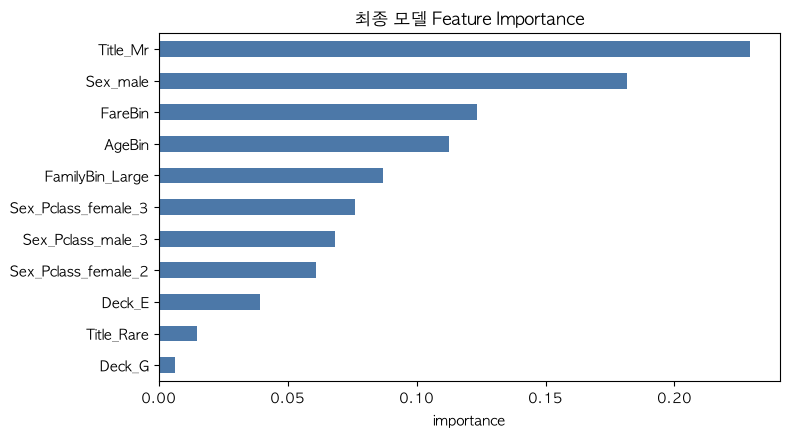

In [30]:
final_imp = pd.Series(rf_final.feature_importances_, index=X_train.columns).sort_values()
fig, ax = plt.subplots(figsize=(8, 4.5))
final_imp.plot(kind="barh", ax=ax, color="#4C78A8")
ax.set_title("최종 모델 Feature Importance"); ax.set_xlabel("importance")
plt.tight_layout(); plt.show()

### 10-3. 제출 요약 (엑셀 결과물 대응)

| 구분 | 실습 항목 | 결과 |
|---|---|---|
| 모델 성능 결과 | 최종 변수 개수 | **11** |
| | Train Accuracy | **0.8764** |
| | Test Accuracy | **0.8545** |

**Feature Creation (파생변수 16개 신규 생성)**
`Title`, `FamilySize`, `IsAlone`, `FamilyBin`, `Deck`, `HasCabin`, `CabinCount`, `NameLength`,
`FarePerPerson`, `FareLog`, `FarePPLog`, `IsChild`, `IsMother`, `Age_Pclass`, `AgeBin`, `FareBin`, `Sex_Pclass`

**Feature Transformation (처리 순서)**
결측 대체(Age: Title별 중앙값 / Embarked: 최빈값 / Fare: 중앙값, 모두 Train 기준)
→ 로그 변환(Fare 계열 왜도 완화) → 구간화(AgeBin 생애주기 5구간, FareBin Train 4분위)
→ 교호작용(Sex_Pclass) → One-Hot Encoding(drop_first=True) + Train/Test 컬럼 정합

**Feature Selection (처리 순서)**
원본 텍스트 변수 제거(Name, Cabin) → 중복·과적합 유발 변수 제거(Fare/Age 계열 중복, NameLength, CabinCount, Deck_T)
→ Feature Importance 확인 → Train CV 기준 전진선택 → 추가/제거 국소탐색 → 최종 11개 확정

---

### 마무리

모델과 데이터 분할을 전혀 건드리지 않고 Feature Engineering만으로
Test Accuracy를 **0.8022 → 0.8545 (+0.0523)** 로 끌어올렸다.

성능 향상의 핵심은 세 가지였다.
1. `Name`을 통째로 더미화하던 구조를 `Title` 5개 범주로 압축해 과적합 통로를 차단했다.
2. `Sex × Pclass` 교호작용과 `FamilyBin` 등 비선형 관계를 변수로 직접 제공했다.
3. 연속형을 구간화하고, Train CV만을 기준으로 변수를 11개까지 줄였다.

변수 선택에 Test를 사용하지 않았음에도 Train CV 1위 조합이 Test에서도 1위였다는 점이
이 결과가 우연한 적합이 아님을 뒷받침한다.